# Reclame Aqui — Análise Exploratória de Dados

**Empresas:** BIG Lojas · Carrefour · Hapvida · Ibyte · Nagem · Pão de Açúcar  
**Total de registros:** ~6016 reclamações  

---

**Estrutura do notebook:**
1. Importações
2. Carregamento dos Dados
3. Inspeção Inicial
4. Limpeza e Processamento dos Dados
5. Colunas Derivadas
6. Estatísticas Descritivas
7. Análise de Sazonalidade
8. Cruzamentos (STATUS vs CATEGORIA / ESTADO / Tamanho do Texto)
9. Visualizações

## 1. Importações

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully.')
import json
import plotly.express as px
import geobr

Libraries loaded successfully.


## 2. Carregamento dos Dados

In [2]:
DATA_DIR = 'datasets'

# Mapeamento de arquivo → nome da empresa
COMPANY_MAP = {
    'RECLAMEAQUI_BIGLOJAS.csv':    'BIG Lojas',
    'RECLAMEAQUI_CARREFUOR.csv':   'Carrefour',
    'RECLAMEAQUI_HAPVIDA.csv':     'Hapvida',
    'RECLAMEAQUI_IBYTE.csv':       'Ibyte',
    'RECLAMEAQUI_NAGEM.csv':       'Nagem',
    'RECLAMEAQUI_PAODEACUCAR.csv': 'Pão de Açúcar',
}

frames = []
for filename, empresa in COMPANY_MAP.items():
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path)
    df['EMPRESA'] = empresa
    frames.append(df)
    print(f'{empresa:15s} — {len(df):5d} linhas carregadas')

raw = pd.concat(frames, ignore_index=True)
print(f'\nDataset combinado: {raw.shape[0]} linhas × {raw.shape[1]} colunas')

BIG Lojas       —  1000 linhas carregadas
Carrefour       —  1000 linhas carregadas
Hapvida         —  1016 linhas carregadas
Ibyte           —  1000 linhas carregadas
Nagem           —  1000 linhas carregadas
Pão de Açúcar   —  1000 linhas carregadas

Dataset combinado: 6016 linhas × 17 colunas


## 3. Inspeção Inicial

In [3]:
# Dimensões e tipos das colunas
print('Dimensões:', raw.shape)
print('\nTipos das colunas:')
print(raw.dtypes)

Dimensões: (6016, 17)

Tipos das colunas:
ID                int64
TEMA             object
LOCAL            object
TEMPO            object
CATEGORIA        object
STATUS           object
DESCRICAO        object
URL              object
ANO               int64
MES               int64
DIA               int64
DIA_DO_ANO        int64
SEMANA_DO_ANO     int64
DIA_DA_SEMANA     int64
TRIMETRES         int64
CASOS             int64
EMPRESA          object
dtype: object


In [4]:
# Primeiras 5 linhas
raw.head()

,ID,TEMA,LOCAL,TEMPO,CATEGORIA,STATUS,DESCRICAO,URL,ANO,MES,DIA,DIA_DO_ANO,SEMANA_DO_ANO,DIA_DA_SEMANA,TRIMETRES,CASOS,EMPRESA
0,120300953,Carne estragada,Guarulhos - SP,2021-01-03,BIG - Lojas Físicas<->Produtos estragados<->Hi...,Respondida,No sábado dia 27/02/21 comprei 11espetos que e...,https://www.reclameaqui.com.br//big-hipermerca...,2021,1,3,3,53,6,1,1,BIG Lojas
1,121856411,Produto com defeito,São Paulo - SP,2021-01-04,BIG - Lojas Físicas<->Estorno do valor pago<->...,Respondida,No dia 19/03/2021 fui walmart de São Judas com...,https://www.reclameaqui.com.br//big-hipermerca...,2021,1,4,4,1,0,1,4,BIG Lojas
2,121896031,Pedido incompleto,São Paulo - SP,2021-01-04,Problema com entrega de produto-compras<->BIG ...,Não resolvido,"Fiz um pedido pelo ifood, paguei e na hora da ...",https://www.reclameaqui.com.br//big-hipermerca...,2021,1,4,4,1,0,1,4,BIG Lojas
3,121898411,Pedido não entregue,São Paulo - SP,2021-01-04,Problema com entrega de produto-compras<->BIG ...,Respondida,Realizei um pedido no Supermercado Big através...,https://www.reclameaqui.com.br//big-hipermerca...,2021,1,4,4,1,0,1,4,BIG Lojas
4,121888931,Pedido incompleto,São Paulo - SP,2021-01-04,BIG - Lojas Físicas,Respondida,Fiz uma compra pelo Ifood e depois de ter paga...,https://www.reclameaqui.com.br//big-hipermerca...,2021,1,4,4,1,0,1,4,BIG Lojas


In [5]:
# Valores nulos por coluna
nulls = raw.isnull().sum()
print('Quantidade de nulos por coluna:')
print(nulls[nulls > 0] if nulls.sum() > 0 else 'Nenhum valor nulo encontrado.')

Quantidade de nulos por coluna:
Nenhum valor nulo encontrado.


In [6]:
# Valores únicos de STATUS e EMPRESA
print('Valores únicos de STATUS:')
print(raw['STATUS'].unique())

print('\nValores únicos de EMPRESA:')
print(raw['EMPRESA'].unique())

Valores únicos de STATUS:
['Respondida' 'Não resolvido' 'Em réplica' 'Resolvido' 'Não respondida']

Valores únicos de EMPRESA:
['BIG Lojas' 'Carrefour' 'Hapvida' 'Ibyte' 'Nagem' 'Pão de Açúcar']


In [7]:
# Resumo estatístico geral
raw.describe(include='all')

,ID,TEMA,LOCAL,TEMPO,CATEGORIA,STATUS,DESCRICAO,URL,ANO,MES,DIA,DIA_DO_ANO,SEMANA_DO_ANO,DIA_DA_SEMANA,TRIMETRES,CASOS,EMPRESA
count,6.016000e+03,6016,6016,6016,6016,6016,6016,6016,6016.000000,6016.000000,6016.000000,6016.000000,6016.000000,6016.000000,6016.000000,6016.000000,6016
unique,NaN,5529,497,1552,1345,5,5987,6016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,Propaganda enganosa,São Paulo - SP,2022-09-13,BIG - Lojas Físicas,Respondida,Venho ao reclame aqui falar da fragilidade dos...,https://www.reclameaqui.com.br//big-hipermerca...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hapvida
freq,NaN,31,1062,100,190,2114,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1016
mean,1.244032e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.968916,7.175532,16.106549,203.206449,29.283411,2.744681,2.717586,15.748670,NaN
std,4.069596e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.622944,3.268292,8.323136,100.871288,14.418999,1.936130,1.048704,21.208963,NaN
min,2.076689e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,NaN
25%,1.186326e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.000000,5.000000,9.000000,128.000000,18.000000,1.000000,2.000000,2.000000,NaN
50%,1.470450e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,8.000000,15.000000,223.000000,32.000000,3.000000,3.000000,6.000000,NaN
75%,1.497742e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,10.000000,24.000000,282.000000,41.000000,4.000000,4.000000,18.000000,NaN


## 4. Limpeza e Processamento dos Dados

In [8]:
df = raw.copy()

# 4.1 Remover espaços extras do ID
df['ID'] = df['ID'].astype(str).str.strip()

# 4.2 Converter TEMPO para datetime
df['TEMPO'] = pd.to_datetime(df['TEMPO'], errors='coerce')

# 4.3 Extrair ESTADO de LOCAL (formato: "Cidade - UF")
df['ESTADO'] = df['LOCAL'].str.strip().str.extract(r' - ([A-Z]{2})$')
df['ESTADO'] = df['ESTADO'].fillna('Desconhecido')

# 4.4 Extrair categoria primária (primeiro elemento antes de <->)
df['CATEGORIA_PRIMARIA'] = df['CATEGORIA'].str.split('<->').str[0].str.strip()

# 4.5 Padronizar texto de STATUS
df['STATUS'] = df['STATUS'].str.strip()

# 4.6 Converter colunas numéricas
int_cols = ['ANO', 'MES', 'DIA', 'DIA_DO_ANO', 'SEMANA_DO_ANO', 'DIA_DA_SEMANA', 'TRIMETRES', 'CASOS']
for col in int_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

print('Limpeza concluída.')
print(f'Nulos em TEMPO após parse: {df["TEMPO"].isnull().sum()}')
print(f'Registros com ESTADO Desconhecido: {(df["ESTADO"] == "Desconhecido").sum()}')
print(f'\nEstados únicos ({df["ESTADO"].nunique()}):', sorted(df['ESTADO'].unique()))

Limpeza concluída.
Nulos em TEMPO após parse: 0
Registros com ESTADO Desconhecido: 16

Estados únicos (27): ['AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'Desconhecido', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']


In [9]:
# Verify dtypes after cleaning
print(df[['ID','TEMPO','ESTADO','STATUS','CASOS'] + int_cols].dtypes)

ID                       object
TEMPO            datetime64[ns]
ESTADO                   object
STATUS                   object
CASOS                     Int64
ANO                       Int64
MES                       Int64
DIA                       Int64
DIA_DO_ANO                Int64
SEMANA_DO_ANO             Int64
DIA_DA_SEMANA             Int64
TRIMETRES                 Int64
CASOS                     Int64
dtype: object


## 5. Colunas Derivadas

In [10]:
# 5.1 Description character length
df['TAMANHO_DESCRICAO'] = df['DESCRICAO'].fillna('').str.len()

# 5.2 Boolean: was the complaint resolved?
df['RESOLVIDO'] = df['STATUS'] == 'Resolvido'

# 5.3 Day of week label (Portuguese)
DAY_LABELS = {0: 'Seg', 1: 'Ter', 2: 'Qua', 3: 'Qui', 4: 'Sex', 5: 'Sáb', 6: 'Dom'}
df['DIA_SEMANA_LABEL'] = df['DIA_DA_SEMANA'].map(DAY_LABELS)

# 5.4 Month label (Portuguese)
MONTH_LABELS = {
    1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
    7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'
}
df['MES_LABEL'] = df['MES'].map(MONTH_LABELS)

print('Derived columns added:')
print(df[['TAMANHO_DESCRICAO', 'RESOLVIDO', 'DIA_SEMANA_LABEL', 'MES_LABEL']].head())

Derived columns added:
   TAMANHO_DESCRICAO  RESOLVIDO DIA_SEMANA_LABEL MES_LABEL
0                573      False              Dom       Jan
1                826      False              Seg       Jan
2                706      False              Seg       Jan
3                286      False              Seg       Jan
4                700      False              Seg       Jan


## 6. Estatísticas Descritivas

> **Objetivo:** Compreender a distribuição das reclamações em termos de STATUS, localização, tamanho da descrição e número de casos. Cada análise é apresentada tanto no nível geral quanto **separada por empresa**, permitindo comparações diretas entre as seis organizações analisadas.

In [ ]:
# 6.1 Distribuição de STATUS (geral e por empresa)
status_counts = df['STATUS'].value_counts()
status_pct = df['STATUS'].value_counts(normalize=True).mul(100).round(1)

status_summary = pd.DataFrame({'Quantidade': status_counts, 'Percentual (%)': status_pct})
print('Distribuição de STATUS (todas as empresas):')
print(status_summary)

# Visualização: barras agrupadas por empresa
status_empresa_abs = pd.crosstab(df['EMPRESA'], df['STATUS'])

fig, ax = plt.subplots(figsize=(14, 6))
status_empresa_abs.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Distribuição de Reclamações por STATUS e Empresa', fontsize=14)
ax.set_xlabel('Empresa')
ax.set_ylabel('Número de Reclamações')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='STATUS', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# 6.2 Percentual de STATUS por empresa (tabela)
status_by_empresa = pd.crosstab(df['EMPRESA'], df['STATUS'], normalize='index').mul(100).round(1)
print('Percentual de STATUS por empresa (%):')
print(status_by_empresa)

print('\n--- Interpretação ---')
for empresa in status_by_empresa.index:
    resolvido = status_by_empresa.loc[empresa, 'Resolvido'] if 'Resolvido' in status_by_empresa.columns else 0
    nao_respondida = status_by_empresa.loc[empresa, 'Não respondida'] if 'Não respondida' in status_by_empresa.columns else 0
    print(f'{empresa}: {resolvido:.1f}% resolvido | {nao_respondida:.1f}% não respondida')

### Análise por Empresa — STATUS

**Observações:**
- A **Hapvida** se destaca negativamente com a maior taxa de reclamações *Não respondidas* (~63%), indicando baixo engajamento no atendimento ao cliente via Reclame Aqui.
- A **Ibyte** possui a maior taxa de resolução (~43%), sugerindo um processo mais eficiente de tratamento de reclamações.
- **Nagem** e **BIG Lojas** apresentam altas taxas de *Em réplica*, o que pode indicar litígio prolongado com os clientes antes de uma resolução final.
- **Carrefour** e **Pão de Açúcar** têm perfis similares: alta taxa de *Respondida* mas relativamente baixa resolução efetiva.

In [ ]:
# 6.3 Top 10 estados por volume de reclamações (geral e por empresa)
top_states = df['ESTADO'].value_counts().head(10)
print('Top 10 estados por número de reclamações (geral):')
print(top_states)

# Top 3 estados por empresa
print('\nTop 3 estados por empresa:')
for empresa in df['EMPRESA'].unique():
    top3 = df[df['EMPRESA'] == empresa]['ESTADO'].value_counts().head(3)
    estados_str = ', '.join([f'{est} ({n})' for est, n in top3.items()])
    print(f'  {empresa}: {estados_str}')

In [ ]:
# 6.4 Estatísticas do tamanho da descrição — geral e por empresa
print('Estatísticas do tamanho da descrição (em caracteres) — Geral:')
print(df['TAMANHO_DESCRICAO'].describe().round(1))

print('\nEstatísticas por STATUS:')
print(df.groupby('STATUS')['TAMANHO_DESCRICAO'].describe().round(1))

print('\nMédia do tamanho da descrição por empresa:')
media_por_empresa = df.groupby('EMPRESA')['TAMANHO_DESCRICAO'].agg(['mean', 'median', 'std']).round(1)
media_por_empresa.columns = ['Média', 'Mediana', 'Desvio Padrão']
print(media_por_empresa)

In [ ]:
# 6.5 Estatísticas de CASOS — geral e por empresa
print('Estatísticas de CASOS (contagem de reclamações semelhantes) — Geral:')
print(df['CASOS'].describe())

print('\nMédia de CASOS por empresa:')
casos_por_empresa = df.groupby('EMPRESA')['CASOS'].agg(['mean', 'median', 'max']).round(2)
casos_por_empresa.columns = ['Média', 'Mediana', 'Máximo']
print(casos_por_empresa.sort_values('Média', ascending=False))

## 7. Análise de Sazonalidade

> **Objetivo:** Identificar padrões temporais nas reclamações — picos por mês, dia da semana, trimestre e evolução ao longo do tempo. Cada análise é exibida com desagregação por empresa para revelar comportamentos específicos de cada organização.

In [ ]:
# 7.1 Reclamações por mês — geral e por empresa
month_order = list(MONTH_LABELS.values())
monthly_geral = df.groupby('MES_LABEL').size().reindex(month_order)

# Gráfico geral
fig, ax = plt.subplots()
monthly_geral.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Reclamações por Mês — Todas as Empresas', fontsize=13)
ax.set_xlabel('Mês')
ax.set_ylabel('Número de Reclamações')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Gráfico por empresa (small multiples)
empresas = df['EMPRESA'].unique()
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)
axes = axes.flatten()
colors = sns.color_palette('tab10', len(empresas))

for i, (empresa, color) in enumerate(zip(empresas, colors)):
    monthly_emp = df[df['EMPRESA'] == empresa].groupby('MES_LABEL').size().reindex(month_order)
    axes[i].bar(month_order, monthly_emp.values, color=color, edgecolor='white')
    axes[i].set_title(empresa, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Mês')
    axes[i].set_ylabel('Reclamações')
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle('Reclamações por Mês — Por Empresa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação — Reclamações por Mês

Os gráficos acima permitem identificar **picos sazonais** específicos de cada empresa. Observe que:
- Empresas de varejo presencial (BIG Lojas, Carrefour, Pão de Açúcar) tendem a ter picos em datas comemorativas (novembro/dezembro) quando o volume de compras é maior.
- Operadoras e planos de saúde (Hapvida) podem apresentar padrões distintos, ligados a períodos de renovação de contratos ou doenças sazonais.
- Comparar os padrões entre empresas revela quais estão mais sujeitas à sazonalidade e quais possuem volume estável ao longo do ano.

In [ ]:
# 7.2 Reclamações por dia da semana — geral e por empresa
day_order = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
weekly_geral = df.groupby('DIA_SEMANA_LABEL').size().reindex(day_order)

fig, ax = plt.subplots()
weekly_geral.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Reclamações por Dia da Semana — Todas as Empresas', fontsize=13)
ax.set_xlabel('Dia da Semana')
ax.set_ylabel('Número de Reclamações')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Por empresa — small multiples
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)
axes = axes.flatten()

for i, (empresa, color) in enumerate(zip(empresas, colors)):
    weekly_emp = df[df['EMPRESA'] == empresa].groupby('DIA_SEMANA_LABEL').size().reindex(day_order)
    axes[i].bar(day_order, weekly_emp.values, color=color, edgecolor='white')
    axes[i].set_title(empresa, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Dia')
    axes[i].set_ylabel('Reclamações')

fig.suptitle('Reclamações por Dia da Semana — Por Empresa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 7.3 Reclamações por trimestre — geral e por empresa
quarterly_geral = df.groupby('TRIMETRES').size()
quarter_labels = {1: 'T1', 2: 'T2', 3: 'T3', 4: 'T4'}

fig, ax = plt.subplots(figsize=(6, 4))
quarterly_geral.plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.set_title('Reclamações por Trimestre — Todas as Empresas', fontsize=13)
ax.set_xlabel('Trimestre')
ax.set_ylabel('Número de Reclamações')
ax.set_xticklabels(['T1', 'T2', 'T3', 'T4'], rotation=0)
plt.tight_layout()
plt.show()

# Por empresa — barras agrupadas
quarterly_empresa = df.groupby(['EMPRESA', 'TRIMETRES']).size().unstack(fill_value=0)
quarterly_empresa.columns = [f'T{c}' for c in quarterly_empresa.columns]

fig, ax = plt.subplots(figsize=(12, 5))
quarterly_empresa.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Reclamações por Trimestre e Empresa', fontsize=13)
ax.set_xlabel('Empresa')
ax.set_ylabel('Número de Reclamações')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Trimestre', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# 7.4 Série temporal mensal com média móvel — por empresa
colors_map = {emp: col for emp, col in zip(empresas, colors)}

# Gráfico geral
time_series = df.groupby(df['TEMPO'].dt.to_period('M')).size()
time_series.index = time_series.index.to_timestamp()
rolling_avg = time_series.rolling(window=3, center=True).mean()

fig, ax = plt.subplots()
ax.bar(time_series.index, time_series.values, width=20, color='steelblue', alpha=0.6, label='Contagem mensal')
ax.plot(time_series.index, rolling_avg.values, color='crimson', linewidth=2, label='Média móvel (3 meses)')
ax.set_title('Evolução das Reclamações ao Longo do Tempo — Todas as Empresas', fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('Número de Reclamações')
ax.legend()
plt.tight_layout()
plt.show()

# Por empresa — subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=False)
axes = axes.flatten()

for i, empresa in enumerate(empresas):
    ts_emp = (
        df[df['EMPRESA'] == empresa]
        .groupby(df[df['EMPRESA'] == empresa]['TEMPO'].dt.to_period('M'))
        .size()
    )
    ts_emp.index = ts_emp.index.to_timestamp()
    roll = ts_emp.rolling(window=3, center=True).mean()

    axes[i].bar(ts_emp.index, ts_emp.values, width=20,
                color=colors_map[empresa], alpha=0.6, label='Mensal')
    axes[i].plot(ts_emp.index, roll.values, color='black', linewidth=1.5, label='Média móvel')
    axes[i].set_title(empresa, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Data')
    axes[i].set_ylabel('Reclamações')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

fig.suptitle('Evolução Temporal das Reclamações — Por Empresa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação — Série Temporal

A média móvel de 3 meses suaviza variações pontuais e evidencia **tendências de médio prazo**. Ao analisar por empresa, é possível identificar:
- **Picos isolados** que podem estar relacionados a incidentes operacionais ou campanhas mal executadas.
- **Tendências crescentes ou decrescentes** que indicam melhora ou deterioração progressiva da satisfação do cliente.
- **Diferenças no período de cobertura** entre as empresas (ex.: Ibyte e Nagem possuem dados desde 2016, enquanto outras concentram registros em 2022).

## 8. Cruzamentos Entre Variáveis

> **Objetivo:** Identificar relações entre STATUS e outras dimensões (categoria, estado, tamanho do texto, casos). Cada cruzamento é analisado também **por empresa** para revelar diferenças no padrão de resolução conforme o porte e o setor de atuação de cada organização.

In [ ]:
# 8.1 STATUS vs CATEGORIA_PRIMARIA — top 15 categorias (geral)
top_cats = df['CATEGORIA_PRIMARIA'].value_counts().head(15).index
cross_cat = pd.crosstab(
    df[df['CATEGORIA_PRIMARIA'].isin(top_cats)]['CATEGORIA_PRIMARIA'],
    df[df['CATEGORIA_PRIMARIA'].isin(top_cats)]['STATUS'],
    normalize='index'
).mul(100).round(1)

print('% de STATUS pelas 15 principais categorias:')
print(cross_cat)

# Taxa de resolução por categoria e empresa
print('\nTaxa de resolução (STATUS = Resolvido) por empresa:')
for empresa in df['EMPRESA'].unique():
    taxa = df[df['EMPRESA'] == empresa]['RESOLVIDO'].mean() * 100
    cats_top = df[df['EMPRESA'] == empresa]['CATEGORIA_PRIMARIA'].value_counts().head(3).index.tolist()
    print(f'  {empresa}: {taxa:.1f}% | Categorias principais: {", ".join(cats_top)}')

In [ ]:
# 8.2 Taxa de resolução por ESTADO — geral e por empresa
top_states_list = df['ESTADO'].value_counts().head(15).index
resolution_by_state = (
    df[df['ESTADO'].isin(top_states_list)]
    .groupby('ESTADO')['RESOLVIDO']
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots()
resolution_by_state.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Taxa de Resolução (%) por Estado — Top 15 Estados', fontsize=13)
ax.set_xlabel('Estado')
ax.set_ylabel('% Resolvido')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Taxa de resolução por empresa e estado (heatmap)
pivot_resolucao = (
    df[df['ESTADO'].isin(top_states_list)]
    .groupby(['EMPRESA', 'ESTADO'])['RESOLVIDO']
    .mean()
    .mul(100)
    .round(1)
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_resolucao, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=60)
ax.set_title('Taxa de Resolução (%) por Empresa × Estado', fontsize=13)
ax.set_xlabel('Estado')
ax.set_ylabel('Empresa')
plt.tight_layout()
plt.show()

### Interpretação — Resolução por Estado e Empresa

O mapa de calor acima combina duas dimensões: **qual empresa** e **em qual estado** ocorre a melhor ou pior taxa de resolução. Valores em verde indicam boa performance; vermelhos indicam gargalos regionais. Isso permite identificar:
- Se determinada empresa tem desempenho consistente em todo o território nacional, ou se há variação regional significativa.
- Quais estados concentram os maiores problemas de não-resolução para cada empresa.

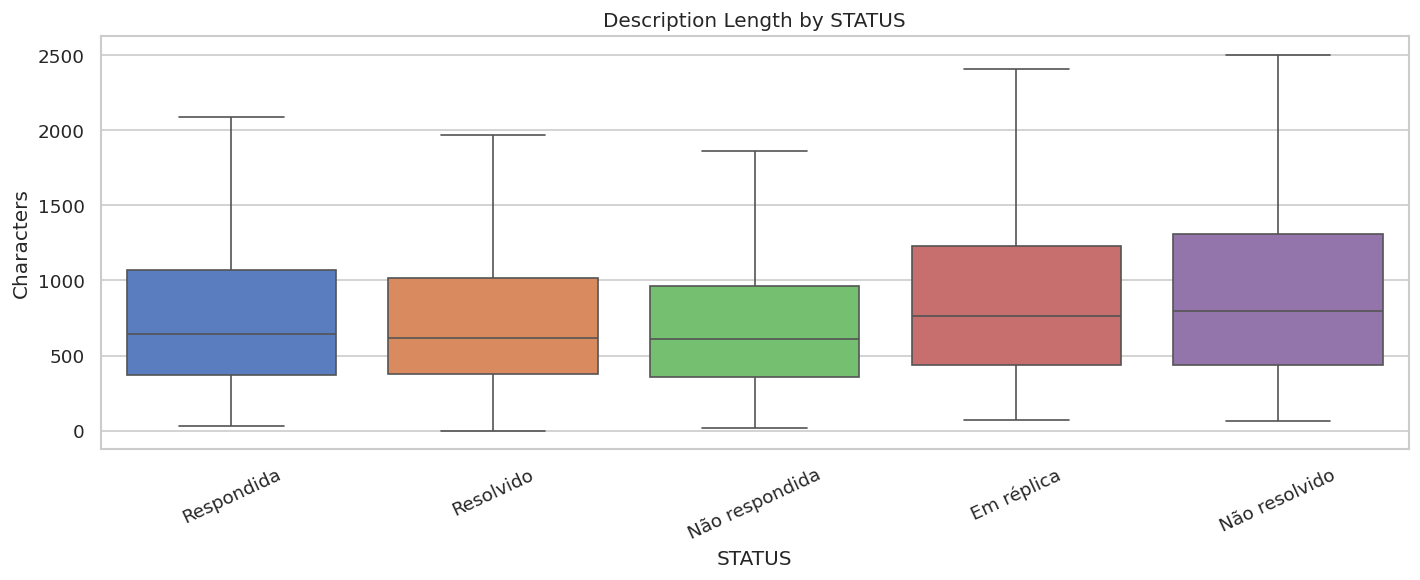

In [22]:
# 8.3 Text size (TAMANHO_DESCRICAO) distribution by STATUS — Boxplot
status_order = df['STATUS'].value_counts().index.tolist()

fig, ax = plt.subplots()
sns.boxplot(
    data=df,
    x='STATUS',
    y='TAMANHO_DESCRICAO',
    order=status_order,
    palette='muted',
    showfliers=False,
    ax=ax
)
ax.set_title('Description Length by STATUS')
ax.set_xlabel('STATUS')
ax.set_ylabel('Characters')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

In [23]:
# 8.4 CASOS vs STATUS — average CASOS per status
casos_by_status = df.groupby('STATUS')['CASOS'].mean().sort_values(ascending=False).round(2)
print('Average CASOS per STATUS:')
print(casos_by_status)

Average CASOS per STATUS:
STATUS
Não respondida    39.92
Respondida        12.88
Resolvido          8.74
Em réplica         8.71
Não resolvido      4.97
Name: CASOS, dtype: Float64
